In [1]:
import matplotlib.font_manager as fm
from matplotlib import rcParams

font_path = '/home/shariat/Documents/fonts/Helvetica.ttf'
fm.fontManager.addfont(font_path)           # add it globally
rcParams['font.family'] = 'Helvetica'  # set default

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress common warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
warnings.filterwarnings("ignore", message=".*X does not have valid feature names.*")

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    accuracy_score
)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [3]:
# ────────────────────────────────────────────────
#                Data Loading & Preparation (TESS)
# ────────────────────────────────────────────────

data = pd.read_csv('/home/shariat/Astronomy/TTV/Data/PS_2025.10.03_12.37.12.csv', comment='#')

features = [
    'pl_orbper', 'pl_orbsmax', 'pl_rade', 'pl_masse', 'pl_orbeccen',
    'pl_insol', 'pl_eqt', 'pl_orbincl', 'pl_trandep', 'pl_trandur',
    'pl_ratdor', 'pl_ratror', 'st_teff', 'st_rad', 'st_mass'
]
target = 'ttv_flag'

tess_data = data[data['disc_facility'] == 'Transiting Exoplanet Survey Satellite (TESS)'].copy()
tess_data = tess_data.dropna(subset=[target])

print(f"TESS rows: {len(tess_data)}")
print("Class distribution BEFORE processing:")
print(tess_data[target].value_counts())
print(tess_data[target].value_counts(normalize=True).round(4))

# Median imputation for missing values
for col in features:
    if col in tess_data.columns:
        tess_data[col] = tess_data[col].fillna(tess_data[col].median())

X = tess_data[features].values
y = tess_data[target].values.astype(int)

scaler = StandardScaler()
X = scaler.fit_transform(X)

TESS rows: 1820
Class distribution BEFORE processing:
ttv_flag
0.0    1651
1.0     169
Name: count, dtype: int64
ttv_flag
0.0    0.9071
1.0    0.0929
Name: proportion, dtype: float64


In [4]:
# ────────────────────────────────────────────────
#          Experiment Settings
# ────────────────────────────────────────────────

experiment_name   = "best_model"

use_smote         = True
use_scale_pos_weight = True   # XGBoost’s recommended way for imbalance

# Single fixed configuration for XGBoost
xgb_params = {
    'n_estimators':       300,
    'max_depth':          6,
    'learning_rate':      0.5,
    'subsample':          0.8,
    'colsample_bytree':   0.8,
    'min_child_weight':   10,
    'gamma':              0.12,
    'reg_lambda':         1.0,
    'reg_alpha':          0.75,
    'random_state':       42,
    'n_jobs':             -1,
    'eval_metric':        'auc',
    'verbosity':          0,
    'scale_pos_weight':   (y == 0).sum() / (y == 1).sum() if use_scale_pos_weight else 1
}

In [5]:
# ────────────────────────────────────────────────
#               20-Fold Cross-Validation
# ────────────────────────────────────────────────

n_splits = 20
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

accuracy_scores  = []
precision_scores = []
recall_scores    = []
f1_scores        = []
auc_scores       = []
cm_list          = []
tpr_list         = []
fpr_list         = []

smote = SMOTE(random_state=42, sampling_strategy='auto')

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}/{n_splits}")
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # Apply SMOTE only to training data
    if use_smote:
        X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
        print(f" After SMOTE → class counts: {np.bincount(y_train_res)} (shape: {X_train_res.shape})")
    else:
        X_train_res, y_train_res = X_train, y_train
        print(" No SMOTE applied")

    # Create and fit XGBoost
    model = XGBClassifier(**xgb_params)
    model.fit(X_train_res, y_train_res)

    # Evaluate on validation fold
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec = recall_score(y_val, y_pred, zero_division=0)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    auc = roc_auc_score(y_val, y_pred_proba)

    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc)

    cm_list.append(confusion_matrix(y_val, y_pred))

    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    common_fpr = np.linspace(0, 1, 100)
    tpr_interp = np.interp(common_fpr, fpr, tpr)
    tpr_list.append(tpr_interp)
    fpr_list.append(common_fpr)

    print(f" Acc: {acc:.4f}  Prec: {prec:.4f}  Rec: {rec:.4f}  F1: {f1:.4f}  AUC: {auc:.4f}")


Fold 1/20
 After SMOTE → class counts: [1569 1569] (shape: (3138, 15))
 Acc: 0.8791  Prec: 0.4375  Rec: 0.7778  F1: 0.5600  AUC: 0.8916

Fold 2/20
 After SMOTE → class counts: [1569 1569] (shape: (3138, 15))
 Acc: 0.9231  Prec: 0.5833  Rec: 0.7778  F1: 0.6667  AUC: 0.9268

Fold 3/20
 After SMOTE → class counts: [1569 1569] (shape: (3138, 15))
 Acc: 0.9231  Prec: 0.6667  Rec: 0.4444  F1: 0.5333  AUC: 0.8266

Fold 4/20
 After SMOTE → class counts: [1569 1569] (shape: (3138, 15))
 Acc: 0.8901  Prec: 0.4667  Rec: 0.7778  F1: 0.5833  AUC: 0.8835

Fold 5/20
 After SMOTE → class counts: [1569 1569] (shape: (3138, 15))
 Acc: 0.8681  Prec: 0.3636  Rec: 0.4444  F1: 0.4000  AUC: 0.8984

Fold 6/20
 After SMOTE → class counts: [1569 1569] (shape: (3138, 15))
 Acc: 0.8352  Prec: 0.2500  Rec: 0.3333  F1: 0.2857  AUC: 0.8401

Fold 7/20
 After SMOTE → class counts: [1569 1569] (shape: (3138, 15))
 Acc: 0.9341  Prec: 0.6000  Rec: 1.0000  F1: 0.7500  AUC: 0.9864

Fold 8/20
 After SMOTE → class counts: [

In [6]:
# ────────────────────────────────────────────────
#                  Summary Results
# ────────────────────────────────────────────────

print(f"\n{'═'*40}")
print(f"EXPERIMENT: {experiment_name} (TESS data only)")
print(f"SMOTE used: {use_smote} | scale_pos_weight used: {use_scale_pos_weight}")
print(f"XGBoost parameters: {xgb_params}")
print(f"{'═'*40}")
print(f"Accuracy:  {np.mean(accuracy_scores):.4f} ± {np.std(accuracy_scores):.4f}")
print(f"Precision: {np.mean(precision_scores):.4f} ± {np.std(precision_scores):.4f}")
print(f"Recall:    {np.mean(recall_scores):.4f} ± {np.std(recall_scores):.4f}")
print(f"F1 Score:  {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"ROC-AUC:   {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"{'═'*40}\n")


════════════════════════════════════════
EXPERIMENT: best_model (TESS data only)
SMOTE used: True | scale_pos_weight used: True
XGBoost parameters: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.5, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 10, 'gamma': 0.12, 'reg_lambda': 1.0, 'reg_alpha': 0.75, 'random_state': 42, 'n_jobs': -1, 'eval_metric': 'auc', 'verbosity': 0, 'scale_pos_weight': np.float64(9.76923076923077)}
════════════════════════════════════════
Accuracy:  0.8885 ± 0.0375
Precision: 0.4557 ± 0.1176
Recall:    0.7243 ± 0.1747
F1 Score:  0.5491 ± 0.1184
ROC-AUC:   0.8979 ± 0.0474
════════════════════════════════════════



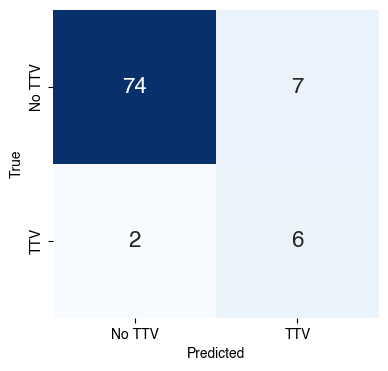

In [7]:
# ────────────────────────────────────────────────
#          Average Confusion Matrix
# ────────────────────────────────────────────────

avg_cm = np.mean(cm_list, axis=0).astype(int)

plt.figure(figsize=(4.2, 4))
sns.heatmap(avg_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks([0.5, 1.5], ['No TTV', 'TTV'])
plt.yticks([0.5, 1.5], ['No TTV', 'TTV'])
#plt.savefig('/home/shariat/Astronomy/TTV/XGBoost/TESS/figures/tess_xgb_20fold_singleconfig_cm_n_300_lr_5_child_10_gamma_12_alpha_75.pdf')
plt.savefig('/home/shariat/Astronomy/TTV/figures/XGBoostTESS_cm.pdf')
plt.show()

<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_13393/1770699563.py:11: SyntaxWarning: invalid escape sequence '\p'
  label=f'Mean AUC = {np.mean(auc_scores):.4f} $\pm$ {np.std(auc_scores):.4f}',


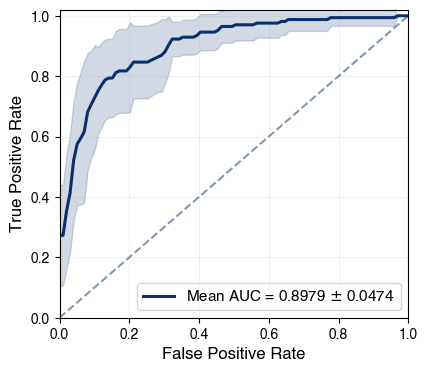

In [8]:
# ────────────────────────────────────────────────
#             Averaged ROC Curve
# ────────────────────────────────────────────────

mean_tpr = np.mean(tpr_list, axis=0)
std_tpr  = np.std(tpr_list, axis=0)
mean_fpr = fpr_list[0]

plt.figure(figsize=(4.5, 4))
plt.plot(mean_fpr, mean_tpr,
         label=f'Mean AUC = {np.mean(auc_scores):.4f} $\pm$ {np.std(auc_scores):.4f}',
         color='#08306b', lw=2.2)
plt.fill_between(mean_fpr, mean_tpr - std_tpr, mean_tpr + std_tpr,
                 color='#08306b', alpha=0.18)
plt.plot([0, 1], [0, 1], linestyle='--', color='#08306b', alpha=0.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.18)
plt.xlim([0, 1])
plt.ylim([0, 1.02])
#plt.savefig('/home/shariat/Astronomy/TTV/XGBoost/TESS/figures/tess_xgb_20fold_singleconfig_roc_n_300_lr_5_child_10_gamma_12_alpha_75.pdf')
plt.savefig('/home/shariat/Astronomy/TTV/figures/XGBoostTESS_roc.pdf')
plt.show()


════════════════════════════════════════════════════════════
Top 5 Most Important Features (XGBoost – gain)
════════════════════════════════════════════════════════════
      feature  importance
0  pl_orbsmax     0.16020
1   pl_ratdor     0.08868
2  pl_orbincl     0.08590
3     pl_rade     0.08043
4    pl_masse     0.08035


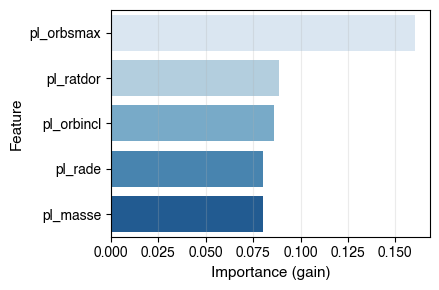

In [9]:
# ────────────────────────────────────────────────
#     TOP 5 FEATURE IMPORTANCE – XGBoost (gain)
# ────────────────────────────────────────────────

importances = model.feature_importances_
feature_names = features  # your original list of 15 features

# Create DataFrame and sort by importance
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

# ─── Print only top 5 ──────────────────────────────────────────
print("\n" + "═"*60)
print("Top 5 Most Important Features (XGBoost – gain)")
print("═"*60)
print(fi_df.head(5).round(5))

# ─── Plot only top 5 ───────────────────────────────────────────
plt.figure(figsize=(4.5, 3))  # smaller figure for top 5
sns.barplot(
    data=fi_df.head(5),
    x='importance',
    y='feature',
    palette='Blues'
)
plt.xlabel('Importance (gain)', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.grid(axis='x', alpha=0.25)
plt.tight_layout()

# Save (you can change the filename/path if needed)
plt.savefig('/home/shariat/Astronomy/TTV/XGBoost/TESS/figures/tess_xgb_top5_feature_importance.pdf')
plt.savefig('/home/shariat/Astronomy/TTV/figures/XGBoostTESS_feature.pdf')
plt.show()